In [1]:
!pip install qiskit
!pip install qiskit-aer
!pip install qiskit-ionq
!pip install python-dotenv

zsh:1: command not found: pip


zsh:1: command not found: pip


zsh:1: command not found: pip


zsh:1: command not found: pip


In [2]:
# Modern imports
import random
import os
# import tensorflow as tf
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, Operator
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
from scipy.optimize import minimize
# from tensorflow.keras.optimizers import Adam
import numpy as np

from dotenv import load_dotenv

try:
    from qiskit_ionq import IonQProvider
except Exception:
    IonQProvider = None

# Fix random seed for reproducible examples (remove or change for real randomness)
random.seed(42)

# Load environment variables from .env if present
load_dotenv()

# Backend setup (prefer IonQ Forte if available, else fallbacks, else Aer)
backend = None
if IonQProvider is not None and os.getenv("IONQ_API_KEY"):
    provider = IonQProvider(token=os.getenv("IONQ_API_KEY"))
    available = [b.name() for b in provider.backends()]
    target = os.getenv("IONQ_BACKEND", "ionq_qpu.forte")
    # Try exact match
    selected = target if target in available else None
    # Try any backend containing 'forte'
    if selected is None:
        forte_like = [n for n in available if "forte" in n.lower()]
        if forte_like:
            selected = forte_like[0]
    # Try common fallbacks
    if selected is None:
        for cand in ["ionq_qpu.harmony", "ionq_qpu.aria-1", "ionq_qpu.aria-2", "ionq_simulator"]:
            if cand in available:
                selected = cand
                break
    if selected is None:
        raise ValueError(f"No suitable IonQ backend found. Available: {available}")
    backend = provider.get_backend(selected)
    print(f"Using IonQ backend: {backend.name()}")

if backend is None:
    backend = AerSimulator()
    print("Using local AerSimulator()")

/Users/jasonli/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Using IonQ backend: ionq_simulator


In [3]:
# Quick IonQ Forte test run
print("Using backend:", backend.name())

# Minimal circuit (|+> measured in Z yields ~50/50)
qc_test = QuantumCircuit(1, 1)
qc_test.h(0)
qc_test.measure(0, 0)

# Transpile for target backend and run a small number of shots
qc_t = transpile(qc_test, backend=backend)
job = backend.run(qc_t, shots=100)
print("Job submitted. Waiting for result...")
res = job.result()
print("Counts:", res.get_counts())

Using backend: ionq_simulator


/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for PauliEvolution can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcx can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mct can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.p

Job submitted. Waiting for result...


Counts: {'0': np.int64(43), '1': np.int64(57)}


In [4]:
def random_bits(n: int) -> List[int]:
    return [random.randint(0, 1) for _ in range(n)]

def random_bases(n: int) -> List[int]:
    """Return 0 for Z-basis (|0>, |1>), 1 for X-basis (|+>, |->)"""
    return [random.randint(0, 1) for _ in range(n)]

def prepare_circuits_for_alice(bits: List[int], bases: List[int]) -> List[QuantumCircuit]:
    """Create one circuit per qubit encoding Alice's preparation."""
    circuits = []
    for b, basis in zip(bits, bases):
        qc = QuantumCircuit(1, 1)
        # encode bit in Z basis by applying X if bit==1
        if b == 1:
            qc.x(0)
        # if basis is X, apply H to prepare |+> / |->
        if basis == 1:
            qc.h(0)
        # leave a measurement placeholder for later (Bob or Eve will measure)
        circuits.append(qc)
    return circuits


def measure_in_basis_circuits(bases: List[int], incoming_circuits: List[QuantumCircuit]) -> List[QuantumCircuit]:
    """Given basis choices and existing single-qubit circuits (prepared qubit),
    append measurement operations for Bob (or Eve)."""
    circuits = []
    for basis, base_qc in zip(bases, incoming_circuits):
        qc = base_qc.copy()
        # if measuring in X basis, rotate with H before measuring
        if basis == 1:
            qc.h(0)
        qc.measure(0, 0)
        circuits.append(qc)
    return circuits


def run_circuits_get_bits(circuits: List[QuantumCircuit], shots: int = 1) -> List[int]:
    """Run circuits on AerSimulator in a batch and return list of measured bits (one shot per circuit).
    We assume one classical bit per circuit and shots=1 per circuit.)"""
    if not circuits:
        return []
    # transpile for backend
    t_circuits = transpile(circuits, backend=backend)
    job = backend.run(t_circuits, shots=shots)
    result = job.result()
    counts_list = [result.get_counts(i) for i in range(len(t_circuits))]
    measured = []
    for counts in counts_list:
        # counts is a dict like {'0': 1} or {'1': 1}
        # since shots=1, pick the single key
        bit = int(next(iter(counts)))
        measured.append(bit)
    return measured


def eve_intercept_resend(alice_circuits: List[QuantumCircuit], eve_bases: List[int]) -> List[QuantumCircuit]:
    """Eve measures each incoming qubit in her chosen basis, then re-prepares a fresh qubit in the result and basis she measured (intercept-resend).
    Returns new circuits prepared to be sent to Bob.
    """
    # First, measure Alice's circuits in Eve's bases
    measure_circuits = measure_in_basis_circuits(eve_bases, [qc.copy() for qc in alice_circuits])
    # run these to get measurement outcomes
    eve_measurements = run_circuits_get_bits(measure_circuits)

    # Now re-prepare qubits according to Eve's measurement results and send them onward
    forwarded = []
    for m, basis in zip(eve_measurements, eve_bases):
        qc = QuantumCircuit(1, 1)
        if m == 1:
            qc.x(0)
        if basis == 1:
            qc.h(0)
        # don't measure here (Bob will measure later)
        forwarded.append(qc)
    return forwarded


def sift_key(alice_bits: List[int], alice_bases: List[int], bob_bits: List[int], bob_bases: List[int]) -> Tuple[List[int], List[int], List[int]]:
    """Return (sifted_alice, sifted_bob, indices_kept) where we keep positions with matching bases."""
    sifted_a = []
    sifted_b = []
    indices = []
    for i, (ab, aa, bb) in enumerate(zip(alice_bases, alice_bits, bob_bits)):
        if ab == ab:  # no-op, kept for readability
            pass
        # keep if bases match
        if alice_bases[i] == bob_bases[i]:
            sifted_a.append(alice_bits[i])
            sifted_b.append(bob_bits[i])
            indices.append(i)
    return sifted_a, sifted_b, indices

def cascade(alice_key, bob_key, passes):

    corrected_bob = bob_key.copy()
    n = len(alice_key)

    for p in range(passes):
        block_size = max(1, n // (2 ** (p + 1)))

        for i in range(0, n, block_size):
            block_end = min(i + block_size, n)
            alice_parity = np.sum(alice_key[i:block_end]) % 2
            bob_parity = np.sum(corrected_bob[i:block_end]) % 2

            if alice_parity != bob_parity:
                low, high = i, block_end
                while high - low > 1:
                    mid = (low + high) // 2

                    temp_a = np.sum(alice_key[low:mid]) % 2
                    temp_b = np.sum(corrected_bob[low:mid]) % 2

                    if temp_a != temp_b:
                        high = mid
                    else:
                        low = mid

                corrected_bob[low] ^= 1

    return corrected_bob


    return corrected_bob

def error_rate(a_bits: List[int], b_bits: List[int]) -> float:
    if not a_bits:
        return 0.0
    mismatches = sum(x != y for x, y in zip(a_bits, b_bits))
    return mismatches / len(a_bits)

def add_noise(bits, noise_prob = 0.05):
    to_return = np.array(bits, dtype = int)
    flips = np.random.rand(len(bits)) < noise_prob
    to_return[flips] ^= 1

    return to_return.tolist()

In [5]:
class AdamOptimizer:
    """
    Adam optimizer implementation for quantum circuit learning.
    As mentioned in the paper (Section III), Adam is preferred over basic gradient descent.
    """
    def __init__(self, learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = None  # First moment estimate
        self.v = None  # Second moment estimate
        self.t = 0     # Time step

    def step(self, params, gradients):
        """Update parameters using Adam algorithm."""
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)

        self.t += 1

        # Update biased first moment estimate
        self.m = self.beta1 * self.m + (1 - self.beta1) * gradients

        # Update biased second moment estimate
        self.v = self.beta2 * self.v + (1 - self.beta2) * (gradients ** 2)

        # Compute bias-corrected moment estimates
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)

        # Update parameters
        params_new = params - self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)

        return params_new

Quantum Circuit Learning Attack

In [6]:
# ----------------------------------------- #
# Quantum Machine Learning Attack Functions #
# ----------------------------------------- #

def hardware_efficient_ansatz(n_qubits: int, n_layers: int, params: np.ndarray) -> QuantumCircuit:
  qc = QuantumCircuit(n_qubits)
  param_index = 0

  for layer in range(n_layers):
    for qubit in range(n_qubits):
      qc.rx(params[param_index], qubit)
      param_index += 1
      qc.ry(params[param_index], qubit)
      param_index += 1
      qc.rz(params[param_index], qubit)
      param_index += 1

    if n_qubits > 1:
      for qubit in range(n_qubits):
        qc.cx(qubit, (qubit + 1) % n_qubits)

  return qc

def pccm_circuit(theta: float) -> QuantumCircuit:
  qc = QuantumCircuit(2, 1)

  # PCCM gates on Eve's ancilla
  qc.rx(np.pi/2, 1)
  qc.ry(-np.pi, 1)
  qc.rz(-np.pi/2, 1)

  qc.cx(0, 1)

  qc.ry(theta, 1)
  qc.rx(-np.pi/2, 1)

  return qc

def compute_fidelity_density_matrix(rho_a: np.ndarray, rho_b: np.ndarray) -> float:
    """
    Compute quantum fidelity between two density matrices.
    F(ρ_a, ρ_b) = [Tr(√(√ρ_a ρ_b √ρ_a))]²

    Args:
        rho_a: First density matrix
        rho_b: Second density matrix

    Returns:
        Fidelity value between 0 and 1
    """
    # Ensure matrices are complex
    rho_a = np.array(rho_a, dtype=complex)
    rho_b = np.array(rho_b, dtype=complex)

    # Add small regularization for numerical stability
    eps = 1e-12
    rho_a = rho_a + eps * np.eye(len(rho_a))
    rho_b = rho_b + eps * np.eye(len(rho_b))

    # Compute sqrt of rho_a using eigendecomposition
    eigvals_a, eigvecs_a = np.linalg.eigh(rho_a)
    eigvals_a = np.maximum(eigvals_a, 0)  # Ensure non-negative
    sqrt_rho_a = eigvecs_a @ np.diag(np.sqrt(eigvals_a)) @ eigvecs_a.conj().T

    # Compute product sqrt(rho_a) @ rho_b @ sqrt(rho_a)
    product = sqrt_rho_a @ rho_b @ sqrt_rho_a

    # Get eigenvalues and compute trace of sqrt
    eigenvalues = np.linalg.eigvalsh(product)
    eigenvalues = np.maximum(eigenvalues, 0)  # Ensure non-negative

    # Fidelity is (sum of sqrt of eigenvalues)^2
    fidelity = np.sum(np.sqrt(eigenvalues))**2

    # Ensure result is in [0, 1]
    fidelity = np.clip(np.real(fidelity), 0, 1)

    return float(fidelity)

def get_density_matrix_from_circuit(qc: QuantumCircuit, num_qubits: int) -> np.ndarray:
    sv = Statevector.from_instruction(qc)
    dm = DensityMatrix(sv)
    return dm.data

def evaluate_attack_fidelities(u_params: np.ndarray, v_params: np.ndarray, n_qubits_u: int, n_layers_u, n_qubits_v: int, n_layers_v: int) -> Dict[str, float]:

  test_states = [(0, 0), (1, 0), (0, 1), (1, 1),]

  f_ab_list = []
  f_ae_list = []

  for bit, basis in test_states:

    qc_alice = QuantumCircuit(n_qubits_u)
    if bit == 1:
      qc_alice.x(0)
    if basis == 1:
      qc_alice.h(0)

    qc_u = hardware_efficient_ansatz(n_qubits_u, n_layers_u, u_params)
    qc_combined = qc_alice.compose(qc_u)

    statevec = Statevector.from_instruction(qc_combined)
    density_matrix_u = DensityMatrix(statevec)

    if n_qubits_u > 1:
      eve_qubits = [i for i in range(1, n_qubits_u)]
      dm_bob = partial_trace(density_matrix_u, eve_qubits)
    else:
      dm_bob = density_matrix_u

    if bit == 0 and basis == 0:
      target = np.array([[1,0], [0,0]])
    elif bit == 1 and basis == 0:
      target = np.array([[0,0], [0, 1]])
    elif bit == 0 and basis == 1:
      target = np.array([[0.5, 0.5], [0.5, 0.5]])
    else:
      target = np.array([[0.5, -0.5], [-0.5, 0.5]])

    f_ab = compute_fidelity_density_matrix(target, dm_bob.data)
    f_ab_list.append(f_ab)

    density_matrix_eve = partial_trace(density_matrix_u, [0])

    if n_qubits_v >= n_qubits_u - 1:
      qc_v = hardware_efficient_ansatz(n_qubits_u - 1, n_layers_v, v_params[:3*(n_qubits_u-1)*n_layers_v])
    else:
      qc_v = hardware_efficient_ansatz(n_qubits_v, n_layers_v, v_params)

    U_v = Operator(qc_v)
    density_matrix_eve_v = U_v @ density_matrix_eve.data @ U_v.adjoint()

    if n_qubits_u - 1 > 1:
      qubits_to_trace = list(range(1, n_qubits_u - 1))
      dm_eve_measured = partial_trace(DensityMatrix(density_matrix_eve_v), qubits_to_trace)
    else:
      dm_eve_measured = DensityMatrix(density_matrix_eve_v)

    # Calculate fidelity between Eve's measured state and Alice's original target
    f_ae = np.real(compute_fidelity_density_matrix(target, dm_eve_measured.data))
    f_ae_list.append(f_ae)
  return {
    'F_AB': np.mean(f_ab_list),
    'F_AE': np.mean(f_ae_list)
  }

def qcl_loss_function(params: np.ndarray, target_f_ab: float, alpha: float, n_qubits_u: int, n_layers_u: int, n_qubits_v: int, n_layers_v: int) -> float:

  n_params_u = n_qubits_u * n_layers_u * 3
  u_params = params[:n_params_u]
  v_params = params[n_params_u:]

  fidelities = evaluate_attack_fidelities(u_params, v_params, n_qubits_u, n_layers_u, n_qubits_v, n_layers_v)

  f_ab = fidelities['F_AB']
  f_ae = fidelities['F_AE']

  loss = alpha * (f_ab - target_f_ab) ** 2 - f_ae

  return loss

def compute_gradient(params, target_f_ab, alpha, n_qubits_u, n_layers_u, n_qubits_v, n_layers_v, shift = np.pi/2):

  gradients = np.zeros_like(params)
  for i in range(len(params)):
    params_plus = params.copy()
    params_plus[i] += shift
    loss_plus = qcl_loss_function(params_plus, target_f_ab, alpha,
                                      n_qubits_u, n_layers_u,
                                      n_qubits_v, n_layers_v)

    params_minus = params.copy()
    params_minus[i] -= shift
    loss_minus = qcl_loss_function(params_minus, target_f_ab, alpha,
                                       n_qubits_u, n_layers_u,
                                       n_qubits_v, n_layers_v)

    # Compute gradient using parameter-shift rule
    gradients[i] = (loss_plus - loss_minus) / 2

  return gradients

def optimize_qcl_attack(target_f_ab: float = 0.85, alpha: float = 10.0, n_qubits_u: int = 2, n_layers_u: int = 2, n_qubits_v: int = 1, n_layers_v: int = 1, max_iter: int = 100, verbose: bool = True, tolerance: float = 1e-6) -> Dict:

  n_params_u = n_qubits_u * n_layers_u * 3
  n_params_v = n_qubits_v * n_layers_v * 3
  total_params = n_params_u + n_params_v

  params = np.random.randn(total_params) * 0.1
  optimizer = AdamOptimizer(learning_rate=0.2)

  loss_history = []
  best_loss = float('inf')
  best_params = params.copy()
  patience = 0

  for iteration in range(max_iter):
    current_loss = qcl_loss_function(params, target_f_ab, alpha, n_qubits_u, n_layers_u, n_qubits_v, n_layers_v)
    loss_history.append(current_loss)

    gradients = compute_gradient(params, target_f_ab, alpha, n_qubits_u, n_layers_u, n_qubits_v, n_layers_v)

    params = optimizer.step(params, gradients)

    if current_loss < best_loss - tolerance:
      best_loss = current_loss
      best_params = params.copy()
      patience = 0
    else:
      patience += 1

    if patience >= 20:
      print(f"Early stopping at iteration: {iteration + 1}")
      break

  params = best_params
  final_loss = best_loss
  success = True

  u_params = params[:n_params_u]
  v_params = params[n_params_u:]
  final_fidelities = evaluate_attack_fidelities(u_params, v_params,
                                                  n_qubits_u, n_layers_u,
                                                  n_qubits_v, n_layers_v)

  return {
    'u_params': u_params,
    'v_params': v_params,
    'F_AB': final_fidelities['F_AB'],
    'F_AE': final_fidelities['F_AE'],
    'loss': final_loss,
    'success': success,
    'loss_history': loss_history,
    'iterations': len(loss_history) if loss_history else max_iter
  }

# ----------------------------------------- #
#          PCCM Analysis Functions          #
# ----------------------------------------- #

def pccm_fidelities(theta: float) -> Tuple[float, float]:
  f_ab = (1 + np.cos(theta/2)) / 2
  f_ae = (1 + np.sin(theta/2)) / 2
  return f_ab, f_ae

def plot_pccm_vs_qcl(qcl_results: List[Dict]):
  # Generate PCCM curve
  theta_range = np.linspace(0, np.pi, 100)
  pccm_f_ab = []
  pccm_f_ae = []

  for theta in theta_range:
    f_ab, f_ae = pccm_fidelities(theta)
    pccm_f_ab.append(f_ab)
    pccm_f_ae.append(f_ae)

  plt.figure(figsize=(10, 6))

  # Plot PCCM
  plt.plot(pccm_f_ab, pccm_f_ae, 'b-', linewidth=2, label='PCCM')

  # Plot QCL results
  if qcl_results:
    qcl_f_ab = [r['F_AB'] for r in qcl_results]
    qcl_f_ae = [r['F_AE'] for r in qcl_results]
    plt.scatter(qcl_f_ab, qcl_f_ae, c='red', s=100, marker='D',
                   label='QCL', zorder=5)

  plt.xlabel('Alice/Bob Fidelity', fontsize=12)
  plt.ylabel('Alice/Eve Fidelity', fontsize=12)
  plt.title('PCCM vs QCL Attack Optimization', fontsize=14)
  plt.legend(fontsize=11)
  plt.grid(True, alpha=0.3)
  plt.xlim(0.5, 1.0)
  plt.ylim(0.5, 1.0)
  plt.tight_layout()
  plt.show()


In [7]:
def run_bb84(n: int = 16, with_eve: bool = False, with_cascade: bool = False, verbose: bool = True):
    # 1) Alice chooses bits and bases
    alice_bits = random_bits(n)
    alice_bases = random_bases(n)

    # 2) Alice prepares qubits (one circuit per qubit)
    alice_circuits = prepare_circuits_for_alice(alice_bits, alice_bases)

    # 3) (Optional) Eve intercepts and resends
    if with_eve:
        eve_bases = random_bases(n)
        forwarded_circuits = eve_intercept_resend(alice_circuits, eve_bases)
    else:
        # no Eve: forward Alice's prepared circuits unchanged
        forwarded_circuits = [qc.copy() for qc in alice_circuits]

    # 4) Bob chooses measurement bases
    bob_bases = random_bases(n)
    # Append measurement operations for Bob
    bob_measure_circuits = measure_in_basis_circuits(bob_bases, forwarded_circuits)

    # 5) Run Bob's measurements
    bob_bits = run_circuits_get_bits(bob_measure_circuits)

    # Add noise
    before = bob_bits.copy()

    bob_bits = add_noise(bob_bits, noise_prob = 0.25)

    print("Bits flipped:", np.sum(np.array(before) != np.array(bob_bits)))

    # 6) Sift keys (Alice and Bob publicly compare bases and keep matching ones)
    sifted_a, sifted_b, indices = sift_key(alice_bits, alice_bases, bob_bits, bob_bases)

    # Test Cascade
    if with_cascade:
        bob_corrected = cascade(np.array(sifted_a), np.array(sifted_b), 5)
        sifted_b = bob_corrected.tolist()

    # 7) Estimate error rate by comparing a random sample or the whole sifted key
    err = error_rate(sifted_a, sifted_b)

    if verbose:
        print(f"Alice bits:      {alice_bits}")
        print(f"Alice bases (0=Z,1=X): {alice_bases}")
        print(f"Bob bits:        {bob_bits}")
        print(f"Bob bases (0=Z,1=X):   {bob_bases}")
        print(f"Sifted indices (bases matched): {indices}")
        print(f"Sifted Alice:    {sifted_a}")
        print(f"Sifted Bob:      {sifted_b}")
        print(f"Estimated error rate on sifted key: {err:.3f}")

    return {
        'alice_bits': alice_bits,
        'alice_bases': alice_bases,
        'bob_bits': bob_bits,
        'bob_bases': bob_bases,
        'sifted_alice': sifted_a,
        'sifted_bob': sifted_b,
        'sifted_indices': indices,
        'error_rate': err
    }


In [8]:
print("EXAMPLE 2: Quantum Circuit Learning (QCL) Attack Optimization")
print("=" * 70)

print("\nOptimizing Eve's attack using Hardware-Efficient Ansatz (HEA).")
print("Goal: Find optimal quantum circuits U(Θ) and V(Λ) to maximize Eve's")
print("      fidelity while maintaining target fidelity for Bob.")
print("\nLoss function (Eq. 3): L(Θ,Λ) = α(F_AB - f)² - F_AE")

# Configuration
print("\n--- Circuit Architecture ---")
print("U(Θ): 2 qubits (Alice-Bob line + 1 Eve ancilla), 2 layers")
print("V(Λ): 1 qubit (Eve's measurement prep), 1 layer")
print("Total trainable parameters: 18")

# Run multiple optimizations with different target fidelities
print("\n--- Running QCL Optimizations ---")
target_fidelities = [0.65, 0.675, 0.70, 0.725, 0.75, 0.775, 0.80, 0.825, 0.85, 0.875, 0.90, 0.925, 0.95]
qcl_results = []

for i, target in enumerate(target_fidelities, 1):
  print(f"\n[Optimization {i}/{len(target_fidelities)}]")
  print(f"Target F_AB = {target:.3f}, α = 10.0")

  result = optimize_qcl_attack(
    target_f_ab=target,
    alpha=10.0,
    n_qubits_u=2,
    n_layers_u=2,
    n_qubits_v=1,
    n_layers_v=1,
    max_iter=100
  )
  qcl_results.append(result)

  print(f">>> RESULT: F_AB = {result['F_AB']:.4f}, F_AE = {result['F_AE']:.4f}")
  print(f"    Loss = {result['loss']:.4f}, Success = {result['success']}")


EXAMPLE 2: Quantum Circuit Learning (QCL) Attack Optimization

Optimizing Eve's attack using Hardware-Efficient Ansatz (HEA).
Goal: Find optimal quantum circuits U(Θ) and V(Λ) to maximize Eve's
      fidelity while maintaining target fidelity for Bob.

Loss function (Eq. 3): L(Θ,Λ) = α(F_AB - f)² - F_AE

--- Circuit Architecture ---
U(Θ): 2 qubits (Alice-Bob line + 1 Eve ancilla), 2 layers
V(Λ): 1 qubit (Eve's measurement prep), 1 layer
Total trainable parameters: 18

--- Running QCL Optimizations ---

[Optimization 1/13]
Target F_AB = 0.650, α = 10.0


Early stopping at iteration: 33
>>> RESULT: F_AB = 0.6591, F_AE = 0.8822
    Loss = -0.8872, Success = True

[Optimization 2/13]
Target F_AB = 0.675, α = 10.0


Early stopping at iteration: 29
>>> RESULT: F_AB = 0.7384, F_AE = 0.8740
    Loss = -0.8994, Success = True

[Optimization 3/13]
Target F_AB = 0.700, α = 10.0


Early stopping at iteration: 23
>>> RESULT: F_AB = 0.6381, F_AE = 0.8079
    Loss = -0.8117, Success = True

[Optimization 4/13]
Target F_AB = 0.725, α = 10.0


Early stopping at iteration: 41
>>> RESULT: F_AB = 0.7301, F_AE = 0.8298
    Loss = -0.8378, Success = True

[Optimization 5/13]
Target F_AB = 0.750, α = 10.0


...

Early stopping at iteration: 23
>>> RESULT: F_AB = 0.9160, F_AE = 0.6554
    Loss = -0.7391, Success = True

[Optimization 10/13]
Target F_AB = 0.875, α = 10.0


Early stopping at iteration: 23
>>> RESULT: F_AB = 0.8569, F_AE = 0.6976
    Loss = -0.7049, Success = True

[Optimization 11/13]
Target F_AB = 0.900, α = 10.0


Early stopping at iteration: 23
>>> RESULT: F_AB = 0.9254, F_AE = 0.6506
    Loss = -0.7034, Success = True

[Optimization 12/13]
Target F_AB = 0.925, α = 10.0


Early stopping at iteration: 23
>>> RESULT: F_AB = 0.8758, F_AE = 0.6887
    Loss = -0.6920, Success = True

[Optimization 13/13]
Target F_AB = 0.950, α = 10.0


Early stopping at iteration: 24
>>> RESULT: F_AB = 0.9695, F_AE = 0.6174
    Loss = -0.6553, Success = True


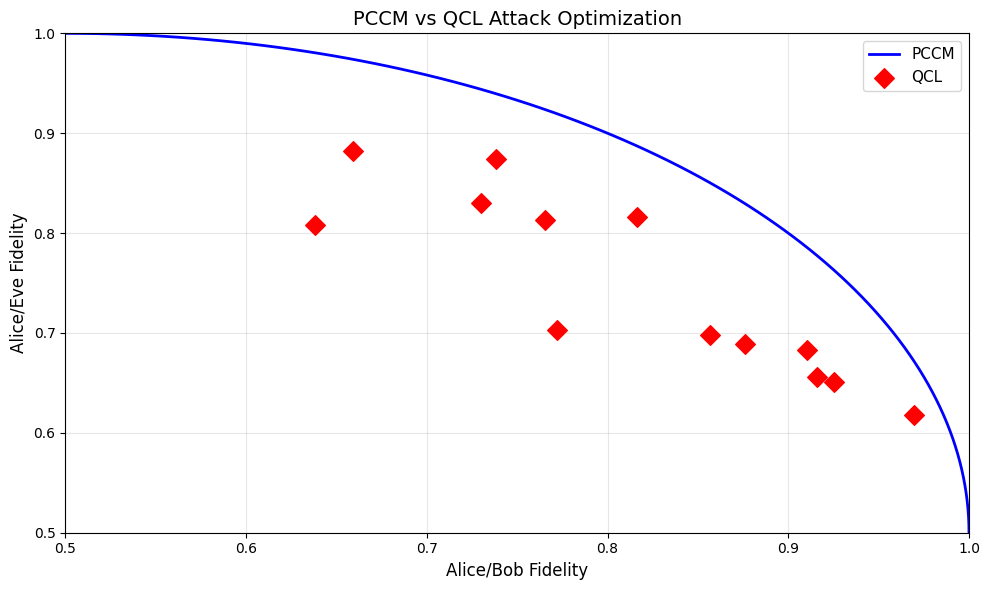

In [9]:
plot_pccm_vs_qcl(qcl_results)


In [10]:
# Run without Cascade
res_no_eve = run_bb84(n=24, with_eve=False, with_cascade = False)

# Run with Cascade
res_with_eve = run_bb84(n=24, with_eve=False, with_cascade = False)

print('\nSummary:')
print(f"No Eve - sifted length: {len(res_no_eve['sifted_alice'])}, error rate: {res_no_eve['error_rate']:.3f}")
print(f"With Eve - sifted length: {len(res_with_eve['sifted_alice'])}, error rate: {res_with_eve['error_rate']:.3f}")

/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for PauliEvolution can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcx can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mct can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.p

Bits flipped: 5
Alice bits:      [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1]
Alice bases (0=Z,1=X): [1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0]
Bob bits:        [0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1]
Bob bases (0=Z,1=X):   [0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1]
Sifted indices (bases matched): [1, 3, 8, 10, 11, 13, 16, 17, 18, 20, 21]
Sifted Alice:    [0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0]
Sifted Bob:      [0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0]
Estimated error rate on sifted key: 0.364


/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for PauliEvolution can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcx can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mct can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.p

Bits flipped: 9
Alice bits:      [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0]
Alice bases (0=Z,1=X): [0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1]
Bob bits:        [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1]
Bob bases (0=Z,1=X):   [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1]
Sifted indices (bases matched): [0, 3, 6, 8, 11, 13, 14, 16, 17, 18, 20, 21, 22, 23]
Sifted Alice:    [1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0]
Sifted Bob:      [0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1]
Estimated error rate on sifted key: 0.429

Summary:
No Eve - sifted length: 11, error rate: 0.364
With Eve - sifted length: 14, error rate: 0.429


In [11]:
# OPTIONAL - Using the sifted key for encryption/decryption
import binascii

def encrypt_message(unencrypted_string: str, key: str) -> str:
    # Convert ASCII string to binary string
    bits = bin(int(binascii.hexlify(unencrypted_string.encode("utf-8", "surrogatepass")), 16))[2:]
    bitstring = bits.zfill(8 * ((len(bits) + 7) // 8))
    # XOR with key
    encrypted_string = ""
    for i in range(len(bitstring)):
        encrypted_string += str(int(bitstring[i]) ^ int(key[i]))
    return encrypted_string

def decrypt_message(encrypted_bits: str, key: str) -> str:
    # XOR back with key
    unencrypted_bits = "".join(
        str(int(encrypted_bits[i]) ^ int(key[i]))
        for i in range(len(encrypted_bits))
    )

    # Convert to bytes
    i = int(unencrypted_bits, 2)
    hex_string = "%x" % i
    n = len(hex_string)
    raw_bytes = binascii.unhexlify(hex_string.zfill(n + (n & 1)))

    try:
        # Try decoding as UTF-8
        return raw_bytes.decode("utf-8", "surrogatepass")
    except UnicodeDecodeError:
        # Show corrupted output as hex and ASCII fallback
        hex_out = raw_bytes.hex()
        ascii_fallback = "".join(chr(b) if 32 <= b <= 126 else "?" for b in raw_bytes)
        return f"[Corrupted] ASCII≈'{ascii_fallback[:64]}...'"

def demonstrate_eve(secret_message="Quantum Computing is cool :)"):
    print("=== Without Eve ===")
    res_with_eve = run_bb84(n=64, with_eve=False, with_cascade=False, verbose=False)

    alice_key = "".join(str(b) for b in res_with_eve["sifted_alice"])
    bob_key   = "".join(str(b) for b in res_with_eve["sifted_bob"])

    needed_len = len(secret_message) * 8
    key_for_alice = (alice_key * ((needed_len // len(alice_key)) + 1))[:needed_len]
    key_for_bob   = (bob_key   * ((needed_len // len(bob_key)) + 1))[:needed_len]

    encrypted = encrypt_message(secret_message, key_for_alice)
    decrypted = decrypt_message(encrypted, key_for_bob)

    print("Error rate:", res_with_eve["error_rate"])
    print("Original:", secret_message)
    print("Decrypted by Bob:", decrypted)
    print()

    print("=== Without Cascade ===")
    res_no_eve = run_bb84(n=64, with_eve=True, with_cascade=False, verbose=False)

    alice_key = "".join(str(b) for b in res_no_eve["sifted_alice"])
    bob_key   = "".join(str(b) for b in res_no_eve["sifted_bob"])

    needed_len = len(secret_message) * 8
    key_for_alice = (alice_key * ((needed_len // len(alice_key)) + 1))[:needed_len]
    key_for_bob   = (bob_key   * ((needed_len // len(bob_key)) + 1))[:needed_len]

    encrypted = encrypt_message(secret_message, key_for_alice)
    decrypted = decrypt_message(encrypted, key_for_bob)

    print("Error rate:", res_no_eve["error_rate"])
    print("Original:", secret_message)
    print("Decrypted by Bob:", decrypted)
    print()

    print("=== With Cascade ===")
    res_with_eve = run_bb84(n=64, with_eve=True, with_cascade=True, verbose=False)

    alice_key = "".join(str(b) for b in res_with_eve["sifted_alice"])
    bob_key   = "".join(str(b) for b in res_with_eve["sifted_bob"])

    needed_len = len(secret_message) * 8
    key_for_alice = (alice_key * ((needed_len // len(alice_key)) + 1))[:needed_len]
    key_for_bob   = (bob_key   * ((needed_len // len(bob_key)) + 1))[:needed_len]

    encrypted = encrypt_message(secret_message, key_for_alice)
    decrypted = decrypt_message(encrypted, key_for_bob)

    print("Error rate:", res_with_eve["error_rate"])
    print("Original:", secret_message)
    print("Decrypted by Bob:", decrypted)


# Run the demonstration
demonstrate_eve()

=== Without Eve ===


/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for PauliEvolution can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcx can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mct can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.p

Bits flipped: 13
Error rate: 0.16666666666666666
Original: Quantum Computing is cool :)
Decrypted by Bob: [Corrupted] ASCII≈'PaqNp%-?R.op0paos0Iwp#?~-":l...'

=== Without Cascade ===


/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for PauliEvolution can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcx can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mct can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.p

/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for PauliEvolution can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcx can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mct can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.p

Bits flipped: 10
Error rate: 0.3
Original: Quantum Computing is cool :)
Decrypted by Bob: [Corrupted] ASCII≈'?!A??%???-e?`|K?3???p?E?.(?<...'

=== With Cascade ===


/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for PauliEvolution can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcx can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mct can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.p

/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for PauliEvolution can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcx can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mct can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/Users/jasonli/Library/Python/3.9/lib/python/site-packages/qiskit/providers/backend_compat.p

Bits flipped: 21
Error rate: 0.0
Original: Quantum Computing is cool :)
Decrypted by Bob: Quantum Computing is cool :)
